#LangGraph로 만드는 AI 에이전트

##LangGraph 란?
* LLM을 활용한 복잡한 워크플로우를 개발하기 위한 파이썬 라이브러리입니다.
* 워크플로우를 그래프 구조로 모델링합니다.


##LangGraph 그래프 구조 접근법
* 각 노드가 특정 처리나 판단을 담당하고, 에지가 그 처리 간의 연결이나 관계성을 표현합니다.
* 이러한 표현 방식을 사용하면 복잡한 LLM 애플리케이션의 작동을 시각적으로 이해하기 쉬운 형태로 설계하고 구현할 수 있습니다.


##LangGraph의 주요 컴포넌트
* 스테이트
* 노드
* 에지

1. 사용자가 질문을 던짐
2. 질문을 분류하고 답변 작성 담당 역할을 선정
3. 답변 작성 담당 역할이 답변 작성
4. 작성된 답변의 품질 검사를 수행, 문제가 있는 경우 2단계로 돌아가 다시 질문을 분류
5. 답변을 사용자에게 제시


[예시] 사용자의 질문에 답변하는 AI 어시스턴트를 만드는 경우

1. 사용자가 질문 입력
2. 사용자 질문 이해하기
3. 필요한 정보 검색하기
4. 검색 결과 분석하기
5. 답변 생성
6. 답변 품직 체크하기
7. 필요에 따라 답변 수정하기
8. 답변 제출하기

* LangGraph를 사용하면 이러한 처리를 노드로 정의하고 처리의 흐름을 에지로 표현할 수 있습니다.


LangGraph의 특징
1. 명시적인 스테이트 관리
   - 스테이트는 대화 이력, 수집된 정보, 중간 결과 등을 포함하는 구조화된 데이터로 표현됩니다.
   - 각 노드는 이 스테이트를 입력으로 받아 처리를 수행한 후 스테이트를 업데이트합니다.
2. 조건 분기와 루프의 자연스러운 표현

3. 단계적인 확장성
   * 새로운 기능을 추가하고 싶은 경우, 기존의 그래프 구조에 새로운 노드를 추가하고 적절한 에지로 연결하기만 하면 됩니다.

4. 디버깅과 테스트의 용이성
   * 각 노드를 독립적으로 테스트할 수 있기 때문에 시스템의 디버깅이나 테스트가 용이해집니다.
   * LangSmith와 함께 사용하면 그래프 단위에서 처리 트레이스가 가능해지므로 문제가 발생할 위치를 쉽게 파악할 수 있습니다.
   * 입력(해당 노드가 받은 데이터), 출력(해당 노드가 생성한 결과),
     실행 시간(처리에 걸린 시간), 호출 로그(LLM 또는 API 호출 세부 정보),
     오류(예외나 실패한 부분) 등을 LangSmith 대시보드에서 각 노드별로 확인할 수 있습니다.

5. 체크포인트와 복구
   * LangGraph는 스테이트의 체크포인트를 생성하고 저장하는 기능을 제공합니다.
     이를 통해 장시간 실행되는 태스크를 중단하고, 나중에 재개하거나 오류가 발생한 경우 특정 지점에서 처리를 재개할 수 있습니다.


##OpenAI API 키 설정

In [1]:
import os
from google.colab import userdata

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_API_KEY"] = userdata.get("LANGSMITH_API_KEY")
os.environ["LANGSMITH_PROJECT"] = "langgraph-project"
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")


##LangChain과 LangGraph 설치

In [3]:
# 핵심 패키지들
!pip install langchain>=0.3.0 langchain-openai langchain-community langchain-text-splitters


In [4]:
# LangChain v0.3+ 호환 버전
!pip install langchain-openai>=0.2.0

In [ ]:
# langgraph 설치 (Version : 1.0.3)
!pip install langgraph


In [ ]:
!pip show langgraph

##역할 정의
* 답변을 생성하기 전에 답변을 담당할 역할을 선택하는 처리 단계로 미리 정의된 역할을 LLM에게 선택하도록 할 것입니다.
* 미리 정의할 수 있는 내용은 LLM에게 생성시키지 않는 것이 비용 측면이 응답 속도 측면에서 유리합니다.

In [6]:
ROLES = {
    "1": {
        "name": "일반 지식 전문가" ,
        "description": "폭넓은 분야의 일반적인 질문에 답변" ,
        "details": "폭넓은 분야의 일반적인 질문에 대해 정확하고 이해하기 쉬운 답변을 제공하세요."
    } ,
    "2": {
        "name": "생성형 AI 제품 전문가" ,
        "description": "생성형 AI 관련 제품, 기술에 관한 전문적인 질문에 답변" ,
        "details": "생성형 AI 관련 제품, 기술에 관한 전문적인 질문에 대해 최신 정보와 깊은 통찰력을 제공하세요."
    } ,
    "3": {
        "name": "카운슬러" ,
        "description": "개인적인 고민이나 심리적인 문제에 대해 지원 제공" ,
        "details": "개인적인 고민이나 심리적인 문제에 대해 공감하고 지원적인 답변을 제공하고, 가능하다면 적절한 조언도 해주세요."
    }
}

##스테이트 정의
* LangGraph 워크플로우에서 실행되는 각 노드에 의해 업데이트된 값을 저장하기 위한 메커니즘입니다.

* LangGraph에서는 스테이트의 데이터 구조를 TypeDict 클래스 또는 Pydantic의 BaseModel 클래스를 이용해 정의합니다.

In [7]:
import operator
from typing import Annotated
from pydantic import BaseModel, Field

class State(BaseModel):  # 상속 관계
  # 속성 :
  query: str = Field(..., description="사용자의 질문")  #... :  필수 필드
  current_role: str = Field(default="", description="선정된 답변 역할")
  # 이 필드는 스테이트 업데이트 시 add 연산으로 병합될 수 있다는 의미적 힌트를 부여한 것이다.
  # 스테이트 업데이트 시 기존 리스트에 새로운 요소를 추가하는 방식으로 업데이트 하라는 의미입니다.
  messages: Annotated[list[str], operator.add] = Field(default=[], description="답변 이력")
  # 답변의 품질을 체크하고, 문제가 있으면 'False', 문제가 없으면 'True'를 반환한다.
  current_judge: bool = Field(default=False, description="품질 검사 결과")
  judgement_reaseon: str = Field(default="", description="품질 검사 판정 이유")




##Chat model 초기화

In [8]:
from langchain_openai import ChatOpenAI
from langchain_core.runnables import ConfigurableField

model = ChatOpenAI(
    model="gpt-4o-mini",    # 모델
    temperature=0.0,        # 0 ~ 2 사이에서 선택, 0.8과 같은 높은 값은 무작위하게 출력, 0.2와 같은 낮은 값은 결정론적 출력을 생성합니다.
    openai_api_key=os.environ["OPENAI_API_KEY"])


# 모델의 설정값(configurable_fields)을 정의해서 나중에 외부에서 동적으로 조정할 수 있게 만듭니다.
model = model.configurable_fields(max_tokens=ConfigurableField(id='max_tokens'))


##노드 정의
* 그래프를 구성하는 처리 단위
* 그래프를 구성하는 노드는 StateGraph 클래스의 add_node 함수를 사용해 추가합니다.

* 노드의 지정 방법
  * 노드의 지정 방법은 2가지가 있습니다.
  1. 함수 또는 Runnable(LCEL 객체)만 지정하는 방법
  2. 노드이름과 함수 또는 Runnable(LCEL 객체)의 쌍을 지정하는 방법

####노드의 구현 방법
* 노드에 함수를 전달하는 경우, 스테이트 객체를 인자로 받고 변경분을 나타내는 딕셔너리 타입의 객체를 반환하도록 구현합니다.


##### selection 노드 구현
* 답변 역할 선정을 수행하는 selection 노드에서는 각 역할에 해당하는 번호만 LLM에게 응답하도록 프롬프트를 설정합니다.
* LLM에 의한 처리 후 번호에 해당하는 역할 이름을 스테이트에 설정합니다.

In [9]:
from typing import Any
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser


def selection_node(state: State) -> dict[str, Any]:

  query = state.query

  # ROLES = [
  #   "1": {"name": "일반 지식 전문가", "description": "폭넓은 분야의 일반적인 질문에 답변"},
  #   "2": {"name": "생성형 AI 제품 전문가", "description": "..."},
  #   "3": {"name": "카운슬러", "description": "..."},
  # ]
  role_options = "\n".join([f"{k}. {v['name']}: {v['description']}" for k, v in ROLES.items()])

  prompt = ChatPromptTemplate.from_template("""
  질문을 분석하고, 가장 적적한 답변 담당 역할을 선택하세요.
  선택지:
  {role_options}

  답변은 선택지의 번호(1, 2, 3)만 반환하세요.

  질문: {query}
  """.strip())

  # with_config는 모델의 설정을 동적으로 조정할 때 사용하며,
  # 선택지의 번호만 반환하기를 기대하므로 max_tokens 값을 1로 변경한다.
  chain = prompt | model.with_config(configurable=dict(max_tokesn=1)) | StrOutputParser()

  role_number = chain.invoke({"role_options": role_options, "query": query})

  selected_role = ROLES[role_number.strip()]["name"]
  print(f'selected_role : {selected_role}')

  # 선정된 역할을 상태에 업데이트한다.
  return {"current_role": selected_role}



#####answering 노드 구현
* 선정된 역할에 따라 질문에 대한 답변을 생성한다.
* LLM이 처리한 후, 답변을 messages 리스트에 추가합니다.

In [10]:
# 사용자의 질문 내용과 선택된 역할을 기반으로 답변을 생성하는 노드를 함수를 사용하여 구현합니다.


from typing import Any

def answering_node(state: State) -> dict[str, Any]: # Any : 다양한 타입

  query = state.query
  role = state.current_role  # 일반 지식 전문가, 생성형 AI 제품 전문가, 카운슬러

  # 이름을 기반으로 ROLES에서 검색
  role_info = next((info for info in ROLES.values() if info["name"] == role), {})

  role_details = role_info.get("details", "")

  print(f"role : {role}")
  print(f"role_details : {role_details}")

  prompt = ChatPromptTemplate.from_template("""
  당신은 {role}로서 답변하세요. 다음 질문에 대해 당신의 역할에 기반한 적절한 답변을 제공하세요.

  역할 상세:
  {role_details}

  질문: {query}

  답변:""".strip())

  chain = prompt | model | StrOutputParser()

  answer = chain.invoke({"role_details": role_details, "query": query, "role": role})

  # 생성된 답변을 상태에 업데이트
  return {"messages": [answer]}



In [ ]:
# answering_node를 LCEL를 사용해 구현한 경우

# from langchain_openai import ChatOpenAI
# from langchain_core.prompts import ChatPromptTemplate
# from langchain_core.runnables import RunnablePassthrough
# from langchain_core.output_parsers import StrOutputParser


# 체인 실행 시 role과 query 값이 동적으로 바인딩됨
# prompt = ChatPromptTemplate.from_messages(
# 당신은 {role} 역할로서 답변하세요.
# 역할 상세:
# {role_details}

# 질문: {query}

# 답변:
#""".strip())


# model = ChatOpenAI(
#     model="gpt-4o-mini",  # 모델
#     temperature=0,        # 0 ~ 2 사이에서 선택, 0.8과 같은 높은 값은 무작위하게 출력, 0.2와 같은 낮은 값은 결정론적 출력을 생성합니다.
#     openai_api_key=os.environ["OPENAI_API_KEY"])


# # state 객체에서 query와 current_role 값을 꺼내 체인 입력으로 할당
# answering_node = (
#     RunnablePassthrough.assign(
#         query=lambda state: state.query,
#         role=lambda state: state.current_role,
#         role_details=lambda state: state.role_details,
#     )
#     | prompt
#     | model
#     | StrOutputParser()
#     | RunnablePassthrough.assign(
#            messages=lambda output, state: state.messages + [output]
#       )



#####check 노드 구현
* 사용자의 질문과 답변 내용을 바탕으로 답변의 품질 체크를 수행하는 프롬프트를 설정합니다.


In [27]:
# answering_node를 함수로 구현한 경우
# 답변의 품질 검사 노드에서 current_judge 필드(품질 검사 결과)와 judgement_reason 필드 ((품질 검사 판정 이유)를 동시에 업데이트해야 하는 경우
# LLM을 활용해서 답변의 품질을 평가하고, 평가 결과와 이유를 state에 저장하는 노드

# Pydantic 모델
class Judgement(BaseModel):
  judge: bool = Field(default=False, description="품질 검사 결과")
  reason: str = Field(default="", description="품질 검사 판정 이유")


def check_node(state: State) -> dict[str, Any]:
  query = state.query
  answer = state.messages[-1]

  prompt = ChatPromptTemplate.from_template("""
  다음 답변의 품질을 체크하고, 문제가 없으면 'True', 문제가 있으면 'False'로 답변하세요.
  또한, 판정 이유도 설명하세요.

  사용자 질문: {query}
  답변: {answer}
  """.strip())


  chain = prompt | model.with_structured_output(Judgement)

  # 개발자가 “result는 Judgement 타입이어야 한다”라고 표시하는 용도 (타입 힌트)
  # 실행에는 영향을 주지 않음
  # 타입 검사에 활용
  result: Judgement = chain.invoke({"query": query, "answer": answer})

  print(f"result.judge : {result.judge}")
  print(f"result.reason : {result.reason}")

  return {
      "current_judge": result.judge,
      "judgement_reason": result.reason
  }



In [ ]:

# answering_node를 LCEL로 구현한 경우
# 답변의 품질 검사 노드에서 current_judge 필드(품질 검사 결과)와 judgement_reason 필드 ((품질 검사 판정 이유)를 동시에 업데이트해야 하는 경우
# LLM을 활용해서 답변의 품질을 평가하고, 평가 결과와 이유를 state에 저장하는 노드

# from langchain_openai import ChatOpenAI
# from langchain_core.prompts import ChatPromptTemplate
# from langchain_core.runnables import RunnablePassthrough
# from langchain_core.output_parsers import StrOutputParser


# prompt = ChatPromptTemplate.from_messages([
# 다음 답변의 품질을 평가하여 JSON 형태로 출력하세요.

# 출력 형식:
# - judge: true 또는 false
# - reason: 문자열 설명

# 질문: {query}
# 답변: {answer}
# """.strip())


# model = ChatOpenAI(
#     model="gpt-4o-mini",
#     temperature=0,
#     openai_api_key=os.environ["OPENAI_API_KEY"])


# # Runnable 체인
# check_node = (
#     RunnablePassthrough.assign(
#         query=lambda state: state.query,
#         messages=lambda state: state.messages[-1]  # 가장 최근에 추가된 답변
#     )
#     | prompt
#     | model
#     | StrOutputParser()
#     | RunnablePassthrough.assign(
#         current_judge=lambda result: result.judge,
#         judgement_reason=lambda result: result.reason
#     )
# )


##그래프 생성
* StateGraph 클래스를 사용하여 그래프의 인스턴스를 생성합니다

* StateGraph : LangGraph에서 그래프 구조를 정의하기 위해서 사용되는 클래스로
  워크플로를 구성하는 노드와 에지를 관리한다.

In [36]:
from langgraph.graph import StateGraph

workflow = StateGraph(state_schema=State)

##노드 추가
* add_noe 함수를 사용해 노드를 추가합니다.
* ("노드 이름", "함수")

In [37]:
workflow.add_node("selection", selection_node)
workflow.add_node("answering", answering_node)
workflow.add_node("check", check_node)

##에지 정의
* 노드를 정의한 후에는 노드 간의 연결 관계를 에지로 정의합니다.
* 3가지 유형의 에지가 있습니다.
  * 엔트리 포인트
    * 그래프의 시작 노드를 지정하는 에지
    * set_entry_point("시작노드가 될 노드 이름")
  * 에지
    * 특정 노드에서 다른 노드로 무조건 전이하는 에지
    * add_edge("selection", "answering") : selection 노드에서 answering 노드로 에지를 연결
  * 조건부 에지
    * 조건에 기반하여 전이할 노드를 결정하는 에지
    * add_conditional_edges('전이 시작 노드 이름', '어떤값을 반환하는 함수',{두번째 인자에서 반환되는 값에 대응하는 전이 대상 노드이름'}) # 딕셔너리타입




In [38]:
workflow.set_entry_point("selection")
workflow.add_edge("selection", "answering")
workflow.add_edge("answering", "check")

###조건부 에지 정의

In [31]:
from langgraph.graph import END

# check 노드에서 다음 노드의 전환에 조건부 에지 정의
# state.current_judge 값이 True이면 END 노드로, False면 selection 노드로 전환한다.

workflow.add_conditional_edges(
    "check",
    lambda state: state.current_judge,  # state는 LangGraph가 각 노드를 실행할 때 현재의 상태(state)를 매개변수로 넣어서 람다 함수를 호출합니다.
    {True: END, False: "selection"}
)


##그래프 컴파일
* compile 함수를 실행하여 CompiledGraph 클래스의 인스턴스로 변환합니다.

In [39]:
app = workflow.compile()

##그래프 실행


In [40]:
initial_state = State(query="생성형 AI에 관해 알려주세요")
result = app.invoke(initial_state)


selected_role : 생성형 AI 제품 전문가
role : 생성형 AI 제품 전문가
role_details : 생성형 AI 관련 제품, 기술에 관한 전문적인 질문에 대해 최신 정보와 깊은 통찰력을 제공하세요.
result.judge : True
result.reason : 답변은 생성형 AI에 대한 포괄적이고 정확한 설명을 제공하며, 주요 기술, 응용 분야, 윤리적 고려사항, 미래 전망 등을 잘 정리하고 있습니다. 정보가 명확하고 체계적으로 제시되어 있어 품질이 높습니다.


In [41]:
print(result["messages"][-1])

생성형 AI(Generative AI)는 데이터를 기반으로 새로운 콘텐츠를 생성하는 인공지능 기술을 의미합니다. 이 기술은 텍스트, 이미지, 음악, 비디오 등 다양한 형태의 콘텐츠를 생성할 수 있으며, 최근 몇 년간 급격한 발전을 이루었습니다. 생성형 AI의 주요 기술적 기반은 주로 딥러닝, 특히 생성적 적대 신경망(GANs)과 변분 오토인코더(VAEs), 그리고 트랜스포머 모델입니다.

### 1. **주요 기술**
- **생성적 적대 신경망(GANs)**: 두 개의 신경망(생성자와 판별자)이 서로 경쟁하며 학습하는 구조로, 고품질의 이미지를 생성하는 데 주로 사용됩니다.
- **변분 오토인코더(VAEs)**: 데이터의 잠재 공간을 학습하여 새로운 데이터를 생성하는 데 유용합니다. 주로 이미지와 같은 연속적인 데이터에 적합합니다.
- **트랜스포머 모델**: 자연어 처리(NLP) 분야에서 혁신을 가져온 모델로, GPT(Generative Pre-trained Transformer)와 같은 모델이 대표적입니다. 이들은 대규모 텍스트 데이터를 학습하여 자연스러운 언어 생성을 가능하게 합니다.

### 2. **응용 분야**
- **콘텐츠 생성**: 블로그 포스트, 기사, 소설 등 다양한 텍스트 콘텐츠를 자동으로 생성할 수 있습니다.
- **이미지 및 비디오 생성**: DALL-E, Midjourney와 같은 모델을 통해 사용자가 입력한 텍스트에 기반하여 이미지를 생성할 수 있습니다.
- **음악 작곡**: AI가 새로운 음악을 작곡하거나 기존 음악을 변형하는 데 사용됩니다.
- **게임 개발**: 게임 환경이나 캐릭터를 자동으로 생성하여 개발 시간을 단축할 수 있습니다.

### 3. **윤리적 고려사항**
생성형 AI의 발전과 함께 윤리적 문제도 대두되고 있습니다. 예를 들어, 저작권 문제, 허위 정보 생성, 그리고 AI가 생성한 콘텐츠의 진위 여부에 대한 우려가 있습니다. 따라서 이러한 기술을 사용할 때는 책임감 있는 접근이 필요합니다.

### 4. **미

##그래프 구조 시각화 표시

* LangGraph에는 그래프 구조를 시각화해 표시하는 기능이 내장되어 있습니다.

In [ ]:
!apt-get install graphviz libgraphviz-dev pkg-config
!pip install pygraphviz

* compile 함수를 실행해서 얻은 CompiledGraph 클래스 인스턴스의 get_graph 함수를 사용하면 그래프 구조 정보를 가져올 수 있고, 여기에 draw_png 함수를 호출 하면 그래프 구조를 PNG 이미지로 가져올 수 있습니다.

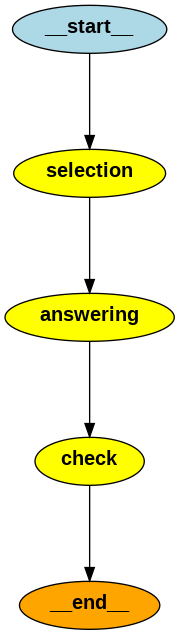

In [43]:
from IPython.display import Image
Image(app.get_graph().draw_png())